# ROGII Wellbore Geology Prediction - Exploratory Data Analysis

This notebook performs exploratory data analysis on the ROGII wellbore geology prediction dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.append('../src')

from data import load_all_data

# Set style
plt.style.use('default')
sns.set_palette('husl')

print("Libraries imported successfully")

Libraries imported successfully


## Data Loading

Load the training data and examine basic structure.

In [2]:
# Load training data
data_dir = Path('../')
train_df = load_all_data(str(data_dir), 'train')

print(f"Training data shape: {train_df.shape}")
print(f"Number of wells: {train_df['well_id'].nunique()}")
print("\nColumns:")
print(train_df.columns.tolist())
print("\nData types:")
print(train_df.dtypes)
print("\nFirst few rows:")
train_df.head()

Training data shape: (5092255, 16)
Number of wells: 773

Columns:
['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR_horiz', 'TVT_input', 'GR_type', 'Geology', 'well_id']

Data types:
MD           float64
X            float64
Y            float64
Z            float64
ANCC         float64
ASTNU        float64
ASTNL        float64
EGFDU        float64
EGFDL        float64
BUDA         float64
TVT          float64
GR_horiz     float64
TVT_input    float64
GR_type      float64
Geology          str
well_id          str
dtype: object

First few rows:


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR_horiz,TVT_input,GR_type,Geology,well_id
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02,NaN,NaN,000d7d20
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05,NaN,NaN,000d7d20
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09,NaN,NaN,000d7d20
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12,NaN,NaN,000d7d20
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15,NaN,NaN,000d7d20


## Basic Statistics

Examine summary statistics and missing values.

Summary statistics for numeric columns:

Missing values:


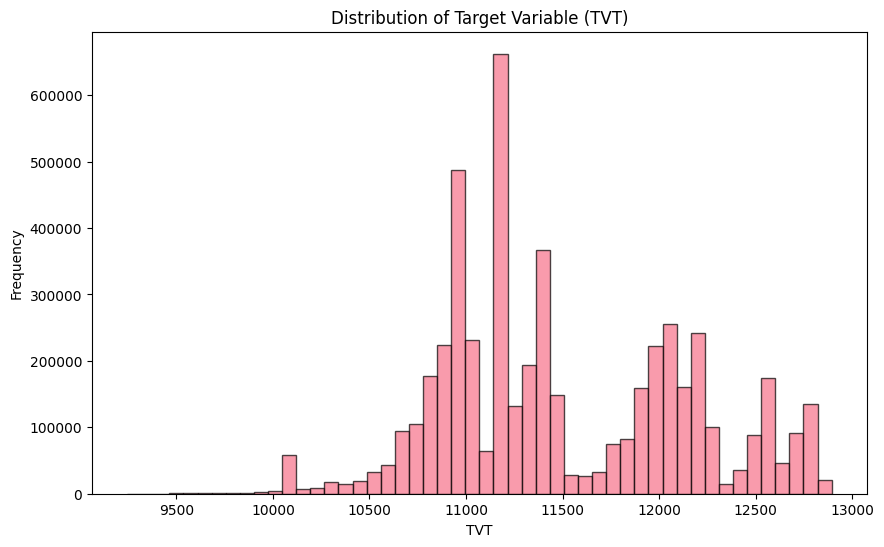

In [3]:
# Summary statistics
print("Summary statistics for numeric columns:")
train_df.describe()

# Missing values
print("\nMissing values:")
missing = train_df.isnull().sum()
missing[missing > 0]

# Target distribution
plt.figure(figsize=(10, 6))
plt.hist(train_df['TVT'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Target Variable (TVT)')
plt.xlabel('TVT')
plt.ylabel('Frequency')
plt.show()

## Correlation Analysis

Examine correlations between features and target.

Top correlations with TVT:
TVT          1.000000
TVT_input    1.000000
X            0.563646
MD           0.356631
Y            0.112720
GR_type     -0.138655
GR_horiz    -0.189338
ASTNL       -0.929140
EGFDL       -0.929738
EGFDU       -0.929894
Name: TVT, dtype: float64


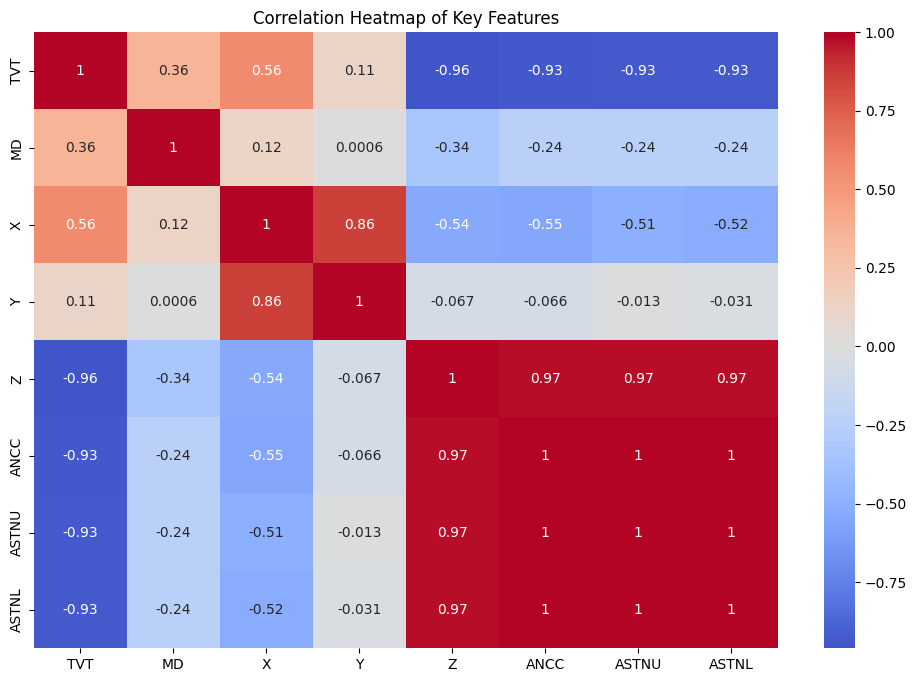

In [ ]:
# Correlation with target
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
correlations = train_df[numeric_cols].corr()['TVT'].sort_values(ascending=False)

print("Top correlations with TVT:")
print(correlations.head(10))

# Correlation heatmap for key features
key_features_candidates = ['TVT', 'MD', 'X', 'Y', 'Z', 'GR', 'ANCC', 'ASTNU', 'ASTNL']
key_features = [col for col in key_features_candidates if col in train_df.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(train_df[key_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Key Features')
plt.show()

## Feature Distributions

Visualize distributions of key features.

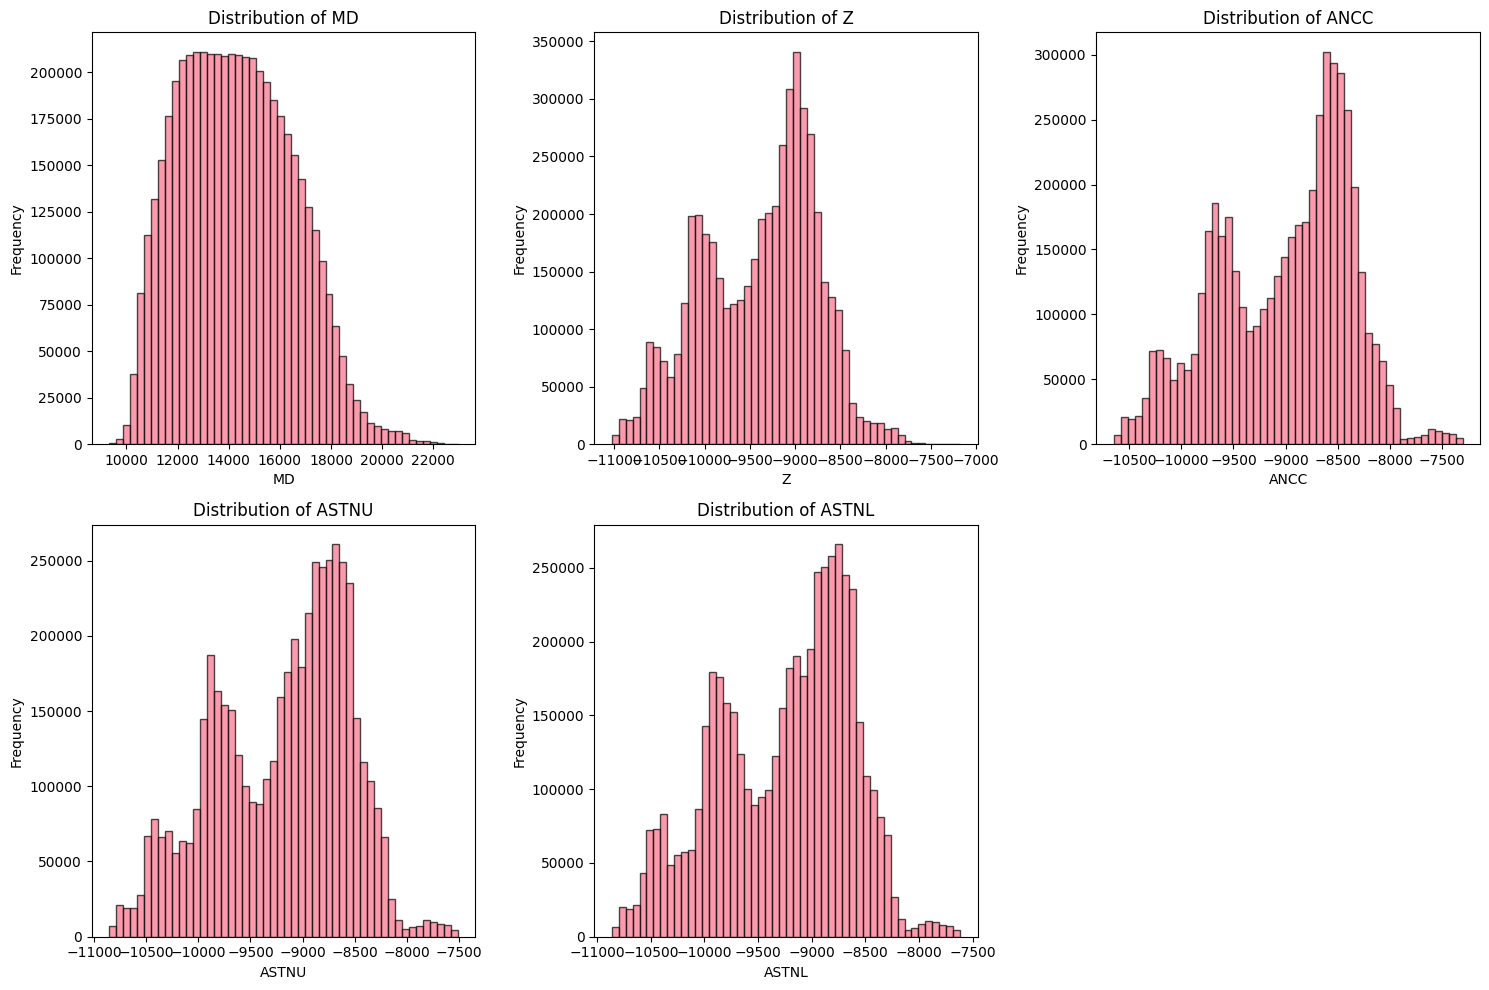

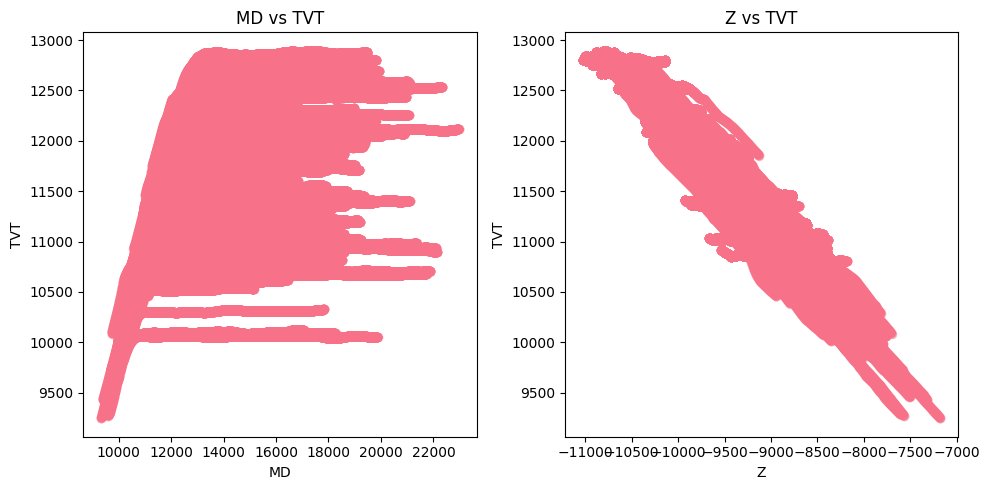

In [ ]:
# Distribution of key features
candidates = ['GR', 'MD', 'Z', 'ANCC', 'ASTNU', 'ASTNL']
features = [col for col in candidates if col in train_df.columns]

# Calculate layout
n_features = len(features)
cols = min(3, n_features)
rows = (n_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
# Flatten axes for iteration, handling cases where it might not be a 2D array
if n_features == 1:
    axes = [axes]
elif rows == 1:
    axes = np.array(axes).flatten()
else:
    axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(train_df[feature], bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Hide any empty subplots
for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Scatter plots vs target
scatter_candidates = ['GR', 'MD', 'Z']
scatter_features = [col for col in scatter_candidates if col in train_df.columns]

if scatter_features:
    fig, axes = plt.subplots(1, len(scatter_features), figsize=(5 * len(scatter_features), 5))
    if len(scatter_features) == 1:
        axes = [axes]
    
    for i, feature in enumerate(scatter_features):
        axes[i].scatter(train_df[feature], train_df['TVT'], alpha=0.1)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('TVT')
        axes[i].set_title(f'{feature} vs TVT')

    plt.tight_layout()
    plt.show()

## Summary

Key insights from the EDA:

- Dataset contains [number] wells with [number] total samples
- Target variable TVT shows [distribution characteristics]
- Key correlated features: [list top features]
- [Any other important findings]

This analysis provides the foundation for feature engineering and model development.
C:\Users\trina\.kaggle\kaggle.json